In [21]:
import numpy as np
import csv
import cumbersome_model
import UNet_family
import UNet_attention
import time
import torch
import os
import random
import shutil
import matplotlib.pyplot as plt


os.environ["CUDA_VISIBLE_DEVICES"]="0"

In [22]:
def read_train_data(file_name):
    with open(file_name, 'r', newline='') as f:
        lines = csv.reader(f)
        data = []
        for line in lines:
            data.append(line)

    data = np.array(data).astype(np.float64)
    return data


def cut_data(file_name):
    with open(file_name, 'r', newline='') as f:
        lines = csv.reader(f)
        raw_data = []
        for line in lines:
            raw_data.append(line)
    raw_data = np.array(raw_data).astype(np.float64)
    total = int(len(raw_data[0]) / 1024)
    for i in range(total):
        table = raw_data[:, i * 1024:(i + 1) * 1024]
        filename = './temp2/' + str(i) + '.csv'
        with open(filename, 'w', newline='') as csvfile:
            writer = csv.writer(csvfile)
            writer.writerows(table)
    return total


def glue_data(file_name, total, output):
    gluedata = 0
    for i in range(total):
        file_name1 = file_name + 'output{}.csv'.format(str(i))
        with open(file_name1, 'r', newline='') as f:
            lines = csv.reader(f)
            raw_data = []
            for line in lines:
                raw_data.append(line)
        raw_data = np.array(raw_data).astype(np.float64)
        #print(i)
        if i == 0:
            gluedata = raw_data
        else:
            smooth = (gluedata[:, -1] + raw_data[:, 1]) / 2
            gluedata[:, -1] = smooth
            raw_data[:, 1] = smooth
            gluedata = np.append(gluedata, raw_data, axis=1)
    #print(gluedata.shape)
    filename2 = output
    with open(filename2, 'w', newline='') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerows(gluedata)
        print("GLUE DONE!" + filename2)


def save_data(data, filename):
    with open(filename, 'w', newline='') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerows(data)

def dataDelete(path):
    try:
        shutil.rmtree(path)
    except OSError as e:
        print(e)
    else:
        print("The directory is deleted successfully")


def decode_data(data, folder=0, std_num=1, mode=5):
    Channel_location = ["FP1", "FP2",
                        "F7", "F3", "FZ", "F4", "F8",
                        "T7", "C3", "CZ", "C4", "T8",
                        "P7", "P3", "PZ", "P4", "P8",
                        "O1", "O2"]
    
    if mode == "ICUNet":
        model = cumbersome_model.UNet1(n_channels=30, n_classes=30)
        resumeLoc = './0420_RealEEG_2_0/modelsave' + '/checkpoint.pth.tar'
    
    elif mode == "ICUNet_block":
        model = cumbersome_model.UNet1(n_channels=30, n_classes=30)
        resumeLoc = './0420_RealEEG_2_1/modelsave' + '/checkpoint.pth.tar'
    
    elif mode == "UNetpp":
        model = UNet_family.NestedUNet3(num_classes=30)
        resumeLoc = './0420_RealEEG_3_0/modelsave' + '/checkpoint.pth.tar'
    
    elif mode == "UNetpp_block":
        model = UNet_family.NestedUNet3(num_classes=30)
        resumeLoc = './0420_RealEEG_3_1/modelsave' + '/checkpoint.pth.tar'
    
    elif mode == "AttUNet":
        model = UNet_attention.UNetpp3_Transformer(num_classes=30)
        resumeLoc = './1018_RealEEG_4_0/modelsave' + '/checkpoint.pth.tar'
    
    elif mode == "AttUNet_block":
        model = UNet_attention.UNetpp3_Transformer(num_classes=30)
        resumeLoc = './0420_RealEEG_4_1/modelsave' + '/checkpoint.pth.tar'
 
    total_params = sum(p.numel() for p in model.parameters())
    #print(f'{mode} Total number of parameters in model: {total_params}')
    
    #model = complex_cnn.Complex_CNN(in_channels=1, out_channels=1, datanum=1024, bilinear=True)
    #model = model.cuda()
    checkpoint = torch.load(resumeLoc, map_location='cpu')
    #start_epoch = checkpoint['epoch']
    model.load_state_dict(checkpoint['state_dict'])
    model.eval()
    with torch.no_grad():
        # run the mdoel
        data = data[np.newaxis, :, :]
        data = torch.Tensor(data)
        if mode == "UNetpp" or mode == "UNetpp_block" or mode == "AttUNet" or mode == "AttUNet_block":
            decode1, decode2, decode = model(data)
        else:
            decode = model(data)
        if int(std_num) != 0:
            decode = decode * std_num
    decode = decode[0,:,:]
    decode = np.array(decode.cpu()).astype(np.float64)
    return decode


# model = tf.keras.models.load_model('./denoise_model/')
def createFolder(path, data_mode):
    if not os.path.isdir(path):
        os.mkdir(path)
    for i in range(3):
        if not os.path.isdir(path+data_mode[i]):
            os.mkdir(path+data_mode[i])
            
def mean_squared_error(y_true, y_pred):
    return ((y_true - y_pred) ** 2).mean()

def eeg_fft(eeg_data_1, eeg_data_2):
    # Function to perform FFT and get frequency bins
    def perform_fft(signal, fs):
        n = len(signal)
        freq = np.fft.fftfreq(n, 1/fs)
        fft_values = np.fft.fft(signal)
        return freq, fft_values

    # Generate sample EEG data: 30 channels, 1024 time points, 256 Hz sampling rate
    fs = 256.0  # Sampling frequency (Hz)

    # Initialize empty arrays to store FFT differences
    fft_diff = np.zeros_like(eeg_data_1, dtype=complex)
    eeg1_fft = np.zeros_like(eeg_data_1, dtype=complex)
    eeg2_fft = np.zeros_like(eeg_data_1, dtype=complex)

    # Loop through each channel to compute FFT and find the difference
    for i in range(eeg_data_1.shape[0]):
        freq, fft_values_1 = perform_fft(eeg_data_1[i, :], fs)
        _, fft_values_2 = perform_fft(eeg_data_2[i, :], fs)

        # Compute the difference in frequency domain
        eeg1_fft[i, :] = np.abs(fft_values_1)
        eeg2_fft[i, :] = np.abs(fft_values_2)
        
    fft_diff = eeg2_fft-eeg1_fft
    return np.abs(fft_diff[:,0:201])

def plotSignal(source, target, signal, ch):
    titlename = "Channel plot with mode" + str(3)

    #print("draw:", mode, signal.shape)

    # Selecting one specific channel (e.g., the first channel)
    channel_to_plot1 = source[ch, 2:1024]
    channel_to_plot2 = target[ch, 2:1024]
    channel_to_plot3 = signal[ch, 2:1024]

    # Create a new figure
    plt.figure(figsize=(10, 6))

    # Plot the selected channel
    plt.plot(channel_to_plot1, 'k')
    plt.plot(channel_to_plot2, 'b')
    plt.plot(channel_to_plot3, 'r')

    # Add labels and title
    plt.xlabel('Time or Sample Index')
    plt.ylabel('Amplitude')
    plt.title(titlename)

    # Save the figure to a file
    plt.savefig(titlename+'.png')

take_time:  0.02574300765991211
MSE:  1.3870617719278744
[1.4712762348291886, 1.3870617719278744, 1.3377164415781047, 1.5097887555847178, 1.8640548432354964, 1.3411898467865637, 1.5372258969147357, 1.264366151437394, 1.4327462607650894, 1.6294679806325019, 1.2438727776788203, 1.5313486606315756, 1.283879555738784, 1.557203650464026, 1.9737078164063542, 1.2550347741224868, 1.9213463851139672, 2.2269082365209307, 1.4761875886423192, 3.6888414824138214, 1.2899589771387676, 1.3275012762926623, 2.140466346348437, 1.4855290770440535, 2.2271849031981095, 1.735491786319154, 1.4773193683175037, 1.7351271924697333, 2.089627539556787, 2.189448723160596]


/tmp/ipykernel_25732/2769917282.py:105: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(resumeLoc, map_location='cpu')


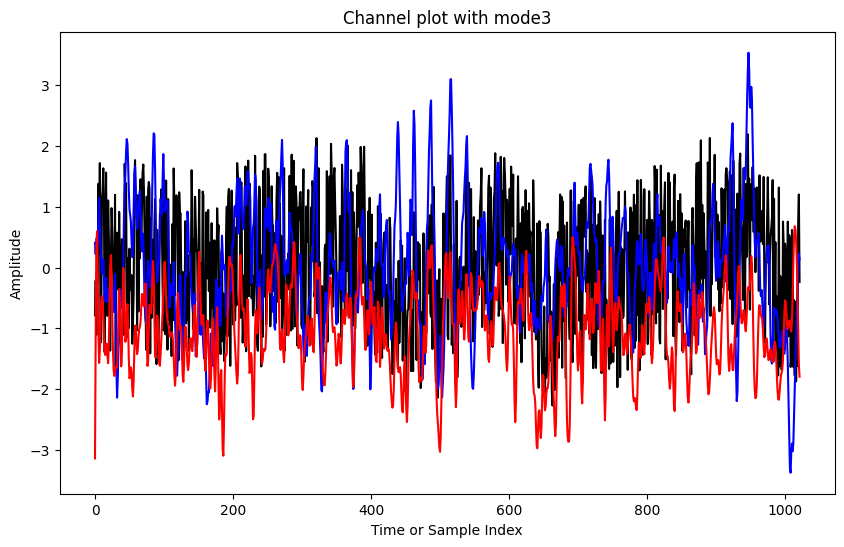

In [23]:
segament = '493_69'
file_name1 = './Real_EEG/test/' + 'Brain' + '/' + segament + '.csv'
file_name2 = './Real_EEG/test/' + 'Other' + '/' + segament + '.csv'

segament = '33'
file_name1 = '../ArtifactRemoval/GCTNet/data/test_EDN/' + 'Brain' + '/' + segament + '.csv'
file_name2 = '../ArtifactRemoval/GCTNet/data/test_EDN/' + 'Eye' + '/' + segament + '.csv'

clean_data = read_train_data(file_name1)
noisy_data = read_train_data(file_name2)
#print(data.shape)

# --- pre-processing ---
data_avg = np.average(noisy_data)
data_std = np.std(noisy_data)
#noisy_data = np.array((noisy_data - data_avg) / data_std).astype(np.float64)
#clean_data = np.array((clean_data - data_avg) / data_std).astype(np.float64)
noisy_data = np.array((noisy_data - data_avg) / data_std).astype(np.float64)
noisy_data = noisy_data + np.random.rand(30, 1024)*10


# --- decode ---
#decode, loss, att_map = decode_data(noisy_data, clean_data)
start_time = time.time()
decode = decode_data(noisy_data, mode='ICUNet') # ICUNet, UNetpp, AttUNet
take_time = time.time() - start_time
print("take_time: ", take_time)

#clean_data = (clean_data - np.mean(clean_data)) / (np.std(clean_data)+ 1e-10)
#noisy_data = (noisy_data - np.mean(noisy_data)) / (np.std(noisy_data)+ 1e-10)
#decode = (decode - np.mean(decode)) / (np.std(decode)+ 1e-10)
#decode = np.hstack((decode, np.zeros((30, 1))))
clean_data = (clean_data - np.mean(clean_data)) / np.std(clean_data+ 1e-10)
noisy_data = (noisy_data - np.mean(noisy_data)) / np.std(noisy_data+ 1e-10)
decode = (decode - np.mean(decode)) / np.std(decode+ 1e-10)


# --- plot & MSE ---
mse_tmp = []
for i in range(30):
    mse_tmp.append(mean_squared_error(clean_data[i], decode[i]))
print("MSE: ", mean_squared_error(clean_data[1], decode[1]))
print(mse_tmp)
plotSignal(noisy_data, clean_data, decode, ch=17)

# --- save data ---
save_data(noisy_data, './testFig/signal_viz/Other/' + segament + '_noise.csv')
save_data(decode,     './testFig/signal_viz/Other/' + segament + '_AttUNet.csv')
save_data(clean_data, './testFig/signal_viz/Other/' + segament + '_clean.csv')

In [15]:
# --- parameters ---
#folder = './1018_RealEEG_4_0/'
#data_mode = ["ChannelNoise", "Eye", "Heart", "LineNoise", "Muscle", "Other"]
#createFolder('./'+folder+'/testMSE/', data_mode)

# ---
model_mode = 'UNetpp' # ICUNet, UNetpp, AttUNet
folder = './0420_RealEEG_3_0/'
data_mode = ["Eye", "Heart", "Muscle"]
createFolder('./'+folder+'/testEDN/', data_mode)

for i in range(6):
    #i = i+5
    print(data_mode[i])
    allFileList = os.listdir("../ArtifactRemoval/GCTNet/data/test_EDN/" + data_mode[i]) # ./Real_EEG/test/
    mse_clde = []
    mse_clno = []
    mse_clde_freq = np.zeros((30,201))
    total = 0
    best_ratio = 100
    for file in allFileList:
        total = total + 1
        file_name1 = '../ArtifactRemoval/GCTNet/data/test_EDN/' + 'Brain' + '/' + file # ./Real_EEG/test/
        file_name2 = '../ArtifactRemoval/GCTNet/data/test_EDN/' + data_mode[i] + '/' + file # ./Real_EEG/test/
        # --- read data ---
        clean_data = read_train_data(file_name1)
        noisy_data = read_train_data(file_name2)
        #print(data.shape)

        # --- pre-processing ---
        data_avg = np.average(noisy_data)
        data_std = np.std(noisy_data)
        noisy_data = np.array((noisy_data - data_avg) / data_std).astype(np.float64)


        # --- decode ---
        decode = decode_data(noisy_data, 0, mode=model_mode)
        #print(decode.shape)
        clean_data = (clean_data - np.mean(clean_data)) / np.std(clean_data+ 1e-10)
        noisy_data = (noisy_data - np.mean(noisy_data)) / np.std(noisy_data+ 1e-10)
        decode = (decode - np.mean(decode)) / np.std(decode+ 1e-10)
        
        # --- MSE ---
        mse_clde_temp = []
        mse_clno_temp = []
        for idx in range(30):
            mse_clde_temp.append(mean_squared_error(clean_data[idx], decode[idx]))
            mse_clno_temp.append(mean_squared_error(clean_data[idx], noisy_data[idx]))
            mse_ratio = mean_squared_error(clean_data[idx], decode[idx]) / mean_squared_error(clean_data[idx], noisy_data[idx])
            is_lower = mse_ratio < best_ratio
            if is_lower:
                best_ratio = mse_ratio
                save_name1 = folder + 'testEDN/' + data_mode[i] + '/Best_brain.csv'
                save_name2 = folder + 'testEDN/' + data_mode[i] + '/Best_noise.csv'
                save_name3 = folder + 'testEDN/' + data_mode[i] + '/Best_decode.csv'
                save_data(clean_data, save_name1)
                save_data(noisy_data, save_name2)
                save_data(decode, save_name3)
                print(file, idx, best_ratio)
            
        mse_clde.append(mse_clde_temp)
        mse_clno.append(mse_clno_temp)
        mse_clde_freq = mse_clde_freq + eeg_fft(clean_data, decode)
        
        # --- save csv file ---
        #save_name = './0915_RealEEG/testing/' + data_mode[i] + '/' + file
        #save_data(decode, save_name)
        #print(save_name, loss)
    save_name1 = folder + 'testEDN/' + data_mode[i] + '/mse_clde.csv'
    save_name2 = folder + 'testEDN/' + data_mode[i] + '/mse_clno.csv'
    save_name3 = folder + 'testEDN/' + data_mode[i] + '/mse_clde_freq.csv'

    save_data(mse_clde, save_name1)
    save_data(mse_clno, save_name2)
    save_data(mse_clde_freq/total, save_name3)

Eye
UNetpp Total number of parameters in model: 1749338


/tmp/ipykernel_25732/2464942999.py:105: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(resumeLoc, map_location='cpu')


(30, 1024)
1280.csv 0 0.960140405170546
1280.csv 12 0.9512276880746362
1280.csv 17 0.9297702009020826
1280.csv 21 0.9018997766614988
UNetpp Total number of parameters in model: 1749338
(30, 1024)
839.csv 6 0.8336950770620689
839.csv 17 0.821706504918133
839.csv 21 0.720998688122948
UNetpp Total number of parameters in model: 1749338
(30, 1024)
UNetpp Total number of parameters in model: 1749338
(30, 1024)
1960.csv 0 0.6398629356696419
1960.csv 11 0.6377401491716824
1960.csv 12 0.61519595042024
1960.csv 16 0.6144732650000769
1960.csv 21 0.6100644149836401
UNetpp Total number of parameters in model: 1749338
(30, 1024)
684.csv 0 0.563355606329179
684.csv 2 0.5054513029843226
684.csv 6 0.4852153350884925
UNetpp Total number of parameters in model: 1749338
(30, 1024)
UNetpp Total number of parameters in model: 1749338
(30, 1024)
UNetpp Total number of parameters in model: 1749338
(30, 1024)
UNetpp Total number of parameters in model: 1749338
(30, 1024)
UNetpp Total number of parameters in m

KeyboardInterrupt: 

In [24]:
def createFolder(path):
    if not os.path.isdir(path):
        os.mkdir(path)

# ---
model_mode = 'ICUNet' # ICUNet, UNetpp, AttUNet
folder = './raw_test/'
data_mode = ["Eye", "Muscle"]
createFolder(folder)

for i in range(2):
    print(data_mode[i])
    createFolder(folder + data_mode[i] + '/' + model_mode)
    allFileList = os.listdir(folder + data_mode[i] + '/noise') # ./Real_EEG/test/

    for file in allFileList:
        print(file)
        
        file_name1 = folder + data_mode[i] + '/noise/' + file
        # ./Real_EEG/test/
        # --- read data ---
        noisy_data = read_train_data(file_name1)
        #print(noisy_data.shape)

        # --- pre-processing ---
        data_avg = np.average(noisy_data)
        data_std = np.std(noisy_data)
        noisy_data = np.array((noisy_data - data_avg) / data_std).astype(np.float64)


        # --- decode ---
        decode = decode_data(noisy_data, 0, mode=model_mode)
        #print(decode.shape)
        noisy_data = (noisy_data - np.mean(noisy_data)) / np.std(noisy_data+ 1e-10)
        decode = (decode - np.mean(decode)) / np.std(decode+ 1e-10)
        
        # --- save decode ---

        save_name1 = folder + data_mode[i] + '/' + model_mode + '/' + file
        save_data(decode, save_name1)
        

Eye
483_10.csv
460_17.csv
447_29.csv
449_54.csv
458_33.csv


/tmp/ipykernel_25732/2769917282.py:105: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(resumeLoc, map_location='cpu')


467_20.csv
479_58.csv
485_24.csv
488_21.csv
461_37.csv
487_28.csv
460_1.csv
452_42.csv
449_74.csv
447_68.csv
468_47.csv
457_19.csv
473_2.csv
461_43.csv
495_29.csv
483_23.csv
472_13.csv
465_30.csv
495_10.csv
457_39.csv
485_3.csv
457_40.csv
469_33.csv
494_32.csv
456_39.csv
463_75.csv
462_58.csv
465_27.csv
487_61.csv
488_45.csv
457_16.csv
478_17.csv
478_63.csv
491_2.csv
450_60.csv
474_7.csv
481_47.csv
479_62.csv
485_36.csv
450_62.csv
478_37.csv
452_5.csv
491_63.csv
480_40.csv
482_13.csv
472_14.csv
492_37.csv
480_73.csv
472_1.csv
484_59.csv
484_23.csv
463_76.csv
485_54.csv
456_78.csv
451_10.csv
487_63.csv
457_13.csv
465_7.csv
487_11.csv
460_56.csv
469_28.csv
495_72.csv
480_12.csv
472_34.csv
468_43.csv
495_70.csv
463_4.csv
450_2.csv
484_24.csv
494_45.csv
472_52.csv
468_25.csv
477_53.csv
487_4.csv
451_46.csv
463_69.csv
460_26.csv
456_55.csv
464_18.csv
462_8.csv
483_43.csv
474_6.csv
493_3.csv
448_53.csv
459_13.csv
494_74.csv
495_0.csv
448_66.csv
476_70.csv
487_62.csv
495_20.csv
465_35.csv
465

470_55.csv
480_64.csv
463_19.csv
462_36.csv
473_52.csv
448_16.csv
461_1.csv
480_36.csv
462_57.csv
493_28.csv
462_67.csv
457_42.csv
460_67.csv
480_51.csv
451_20.csv
448_9.csv
476_34.csv
477_50.csv
490_7.csv
465_24.csv
493_35.csv
470_21.csv
478_21.csv
463_12.csv
469_27.csv
446_43.csv
487_53.csv
469_85.csv
460_16.csv
466_34.csv
446_30.csv
481_43.csv
484_27.csv
472_39.csv
466_52.csv
479_50.csv
451_7.csv
472_49.csv
493_46.csv
481_4.csv
493_71.csv
461_58.csv
475_0.csv
468_33.csv
449_51.csv
475_14.csv
494_17.csv
458_41.csv
480_42.csv
455_73.csv
491_6.csv
480_11.csv
485_45.csv
485_10.csv
447_72.csv
459_10.csv
447_40.csv
470_69.csv
492_55.csv
458_5.csv
457_20.csv
464_40.csv
491_52.csv
470_9.csv
461_32.csv
458_74.csv
480_2.csv
464_27.csv
476_30.csv
461_13.csv
474_4.csv
449_32.csv
464_54.csv
461_52.csv
451_72.csv
458_39.csv
461_67.csv
448_40.csv
493_59.csv
450_68.csv
478_30.csv
476_40.csv
464_73.csv
470_24.csv
472_6.csv
478_40.csv
448_46.csv
447_51.csv
481_34.csv
450_39.csv
446_55.csv
483_63.csv


450_32.csv
484_30.csv
479_54.csv
446_39.csv
479_34.csv
452_20.csv
484_14.csv
460_23.csv
462_46.csv
480_22.csv
495_31.csv
456_11.csv
463_13.csv
491_68.csv
450_27.csv
448_47.csv
483_53.csv
465_19.csv
469_5.csv
494_29.csv
447_8.csv
492_20.csv
493_13.csv
448_26.csv
450_67.csv
488_61.csv
464_66.csv
475_58.csv
493_68.csv
474_46.csv
488_76.csv
469_80.csv
483_4.csv
483_69.csv
470_66.csv
460_57.csv
490_10.csv
492_17.csv
484_39.csv
447_58.csv
482_65.csv
491_44.csv
491_4.csv
487_64.csv
482_45.csv
460_13.csv
488_51.csv
484_43.csv
452_54.csv
458_4.csv
484_63.csv
467_51.csv
460_71.csv
465_50.csv
452_71.csv
482_60.csv
480_31.csv
452_9.csv
461_55.csv
493_50.csv
495_3.csv
464_9.csv
463_77.csv
461_59.csv
456_54.csv
479_15.csv
468_7.csv
490_22.csv
488_74.csv
488_8.csv
491_66.csv
476_62.csv
473_37.csv
488_60.csv
495_32.csv
484_51.csv
455_75.csv
469_3.csv
462_4.csv
481_37.csv
467_31.csv
448_54.csv
492_31.csv
455_0.csv
469_6.csv
474_12.csv
495_48.csv
481_12.csv
485_22.csv
479_16.csv
470_64.csv
477_41.csv
45

469_20.csv
472_28.csv
457_56.csv
469_72.csv
459_48.csv
484_50.csv
467_8.csv
456_28.csv
467_18.csv
473_1.csv
490_32.csv
490_20.csv
450_57.csv
467_61.csv
464_46.csv
451_53.csv
467_27.csv
494_66.csv
488_54.csv
461_66.csv
463_48.csv
490_9.csv
451_33.csv
461_22.csv
484_40.csv
448_3.csv
462_10.csv
452_7.csv
479_68.csv
452_36.csv
468_74.csv
449_27.csv
493_67.csv
492_50.csv
456_2.csv
495_6.csv
493_54.csv
473_51.csv
473_27.csv
449_66.csv
461_11.csv
485_27.csv
465_31.csv
481_51.csv
482_48.csv
494_46.csv
469_8.csv
450_7.csv
464_67.csv
485_20.csv
494_64.csv
488_25.csv
464_37.csv
456_51.csv
475_12.csv
495_36.csv
465_71.csv
492_22.csv
479_21.csv
493_47.csv
476_7.csv
459_46.csv
470_3.csv
477_26.csv
455_23.csv
480_24.csv
467_54.csv
476_65.csv
457_66.csv
484_22.csv
447_7.csv
477_42.csv
458_58.csv
464_58.csv
473_75.csv
490_2.csv
467_57.csv
463_7.csv
447_69.csv
488_13.csv
494_18.csv
495_57.csv
463_36.csv
456_30.csv
474_8.csv
495_78.csv
447_6.csv
478_0.csv
483_20.csv
490_6.csv
457_28.csv
460_52.csv
474_70

477_18.csv
464_42.csv
483_47.csv
446_34.csv
482_2.csv
461_9.csv
470_48.csv
451_22.csv
446_54.csv
464_39.csv
492_1.csv
465_69.csv
468_5.csv
452_19.csv
457_58.csv
464_0.csv
475_20.csv
470_5.csv
478_64.csv
472_5.csv
449_53.csv
484_31.csv
468_9.csv
491_51.csv
474_43.csv
457_49.csv
487_33.csv
487_72.csv
480_67.csv
465_76.csv
483_26.csv
457_48.csv
455_17.csv
458_49.csv
493_19.csv
455_7.csv
465_40.csv
491_74.csv
463_39.csv
456_65.csv
479_30.csv
491_16.csv
472_77.csv
451_17.csv
478_61.csv
480_60.csv
460_30.csv
490_41.csv
466_9.csv
468_39.csv
479_24.csv
456_70.csv
483_24.csv
446_33.csv
495_63.csv
456_52.csv
494_47.csv
493_41.csv
493_2.csv
480_21.csv
466_47.csv
456_20.csv
495_65.csv
481_27.csv
460_76.csv
451_31.csv
484_13.csv
465_63.csv
490_36.csv
474_21.csv
479_31.csv
456_13.csv
476_1.csv
457_7.csv
450_10.csv
466_51.csv
472_46.csv
479_48.csv
448_5.csv
450_15.csv
460_36.csv
481_22.csv
481_36.csv
480_39.csv
480_23.csv
479_65.csv
455_55.csv
473_19.csv
480_72.csv
482_49.csv
462_56.csv
476_16.csv
47

464_51.csv
470_63.csv
446_20.csv
467_45.csv
450_18.csv
448_4.csv
483_48.csv
479_17.csv
470_42.csv
461_17.csv
467_30.csv
482_56.csv
478_13.csv
462_59.csv
461_56.csv
450_56.csv
478_34.csv
479_4.csv
455_60.csv
461_25.csv
478_41.csv
476_32.csv
487_40.csv
477_49.csv
485_55.csv
458_59.csv
448_60.csv
446_44.csv
461_72.csv
479_6.csv
483_21.csv
485_43.csv
494_28.csv
467_74.csv
475_2.csv
484_26.csv
492_9.csv
482_64.csv
487_15.csv
450_74.csv
461_68.csv
464_24.csv
475_26.csv
469_50.csv
475_33.csv
465_72.csv
466_66.csv
467_65.csv
478_69.csv
474_19.csv
466_4.csv
476_59.csv
483_3.csv
485_0.csv
450_53.csv
452_3.csv
489_57.csv
449_69.csv
482_57.csv
446_25.csv
466_26.csv
480_20.csv
491_73.csv
458_53.csv
467_35.csv
449_59.csv
474_0.csv
469_0.csv
452_47.csv
455_56.csv
494_73.csv
450_69.csv
492_27.csv
476_44.csv
491_75.csv
475_15.csv
466_73.csv
448_33.csv
491_24.csv
462_31.csv
475_34.csv
477_37.csv
474_42.csv
465_6.csv
452_1.csv
458_78.csv
452_12.csv
473_39.csv
487_6.csv
474_13.csv
489_38.csv
446_58.csv
47

488_51.csv
484_43.csv
452_54.csv
458_4.csv
484_63.csv
467_51.csv
465_50.csv
452_71.csv
482_60.csv
480_31.csv
452_9.csv
461_55.csv
464_9.csv
461_59.csv
479_15.csv
488_74.csv
488_8.csv
491_66.csv
476_62.csv
489_67.csv
473_37.csv
488_60.csv
484_51.csv
455_75.csv
469_3.csv
462_4.csv
467_31.csv
448_54.csv
492_31.csv
455_0.csv
469_6.csv
474_12.csv
489_13.csv
485_22.csv
479_16.csv
470_64.csv
477_41.csv
452_2.csv
487_56.csv
477_0.csv
494_40.csv
491_38.csv
467_52.csv
485_6.csv
487_48.csv
483_56.csv
484_54.csv
489_35.csv
477_57.csv
461_31.csv
476_18.csv
455_14.csv
494_11.csv
448_20.csv
458_70.csv
483_46.csv
467_25.csv
487_19.csv
469_59.csv
477_40.csv
494_53.csv
458_68.csv
482_62.csv
489_84.csv
449_71.csv
475_42.csv
448_56.csv
478_32.csv
455_47.csv
450_37.csv
489_47.csv
483_32.csv
461_5.csv
464_41.csv
458_1.csv
494_58.csv
485_2.csv
488_71.csv
487_65.csv
494_38.csv
455_61.csv
462_12.csv
455_37.csv
476_53.csv
484_32.csv
462_53.csv
449_44.csv
467_73.csv
480_19.csv
450_21.csv
480_26.csv
455_26.csv
45

474_50.csv
467_70.csv
470_11.csv
484_44.csv
475_43.csv
491_42.csv
474_1.csv
474_56.csv
465_17.csv
475_8.csv
467_43.csv
484_47.csv
494_49.csv
467_66.csv
487_10.csv
449_60.csv
494_21.csv
469_21.csv
466_16.csv
458_35.csv
489_17.csv
458_18.csv
488_64.csv
477_29.csv
479_60.csv
491_48.csv
455_74.csv
491_20.csv
474_51.csv
450_26.csv
476_27.csv
472_16.csv
466_53.csv
469_77.csv
464_14.csv
489_16.csv
487_7.csv
449_37.csv
489_27.csv
464_76.csv
491_7.csv
466_49.csv
472_36.csv
472_48.csv
482_10.csv
469_81.csv
469_1.csv
478_27.csv
476_13.csv
458_72.csv
470_1.csv
467_37.csv
489_14.csv
491_36.csv
455_15.csv
452_10.csv
462_32.csv
480_5.csv
452_63.csv
474_39.csv
455_35.csv
470_30.csv
446_27.csv
462_41.csv
480_57.csv
480_59.csv
452_35.csv
461_71.csv
492_8.csv
478_4.csv
494_15.csv
482_74.csv
462_21.csv
449_33.csv
484_25.csv
480_61.csv
473_5.csv
479_27.csv
477_47.csv
449_21.csv
487_22.csv
458_31.csv
488_49.csv
483_15.csv
484_62.csv
465_9.csv
452_72.csv
477_8.csv
458_57.csv
455_30.csv
474_66.csv
491_11.csv


In [ ]:
def main(nname):
    for j in range(1):
        second1 = time.time()
        j = j+1
        name = "G:/共用雲端硬碟/CNElab_members/10.data/film_0915/EEG/" + nname + ".csv"

        # -------------------cutting_data---------------------------
        try:
            os.mkdir("./temp2/")
        except OSError as e:
            print(e)

        #try:
        total = cut_data(name)
        #except:
        #print("jump out!")
        #continue
        # -------------------decode_data---------------------------
        for i in range(total):
            # file_name = './Real_EEG/test/Brain/510_{}.csv'.format(str(i))
            # data_clean = read_train_data(file_name)
            # torch_PSD(data_clean[0])

            file_name = './temp2/{}.csv'.format(str(i))
            data_noise = read_train_data(file_name)
            data_new = data_noise
            #print(data_new.shape)
            for k in range(30):
                antiCap_index = [ 1, 30,  4,  3,  2, 28, 29,  5,  6,  7, 26, 25,  9,  8, 22, 23, 24, 10, 11,  11, 21, 20, 14, 13, 12, 18, 19, 15, 16, 17]
                if k == 9:
                    data_new[k,:] = (data_noise[6,:] + data_noise[26,:])/2
                elif k == 19:
                    data_new[k,:] = (data_noise[10,:] + data_noise[20,:])/2
                else:
                    data_new[k,:] = data_noise[antiCap_index[k]-1,:]
            
            data_clean = data_noise
            # torch_PSD(data_noise[0])

            # print(data.shape, std)
            std = np.std(data_noise)
            avg = np.average(data_noise)
            '''
            if int(std) != 0:
                data_clean = np.array((data_clean - avg) / std).astype(np.float)
                data_noise = np.array((data_noise - avg) / std).astype(np.float)
            else:
                data_clean = np.array(data_clean - avg).astype(np.float)
                data_noise = np.array(data_noise - avg).astype(np.float)    
            '''

            # UNet
            d_data = decode_data(data_noise, std/2, 1)#std
            d_data = d_data[0]

            '''
            # EEGdenoiseNet
            for k in range(30):
                if k == 0:
                    tmp1 = np.expand_dims(data_noise[k], axis=0)
                    d_data = decode_data(tmp1, std, 5)
                    d_data = d_data[0]
                else:
                    tmp1 = np.expand_dims(data_noise[k], axis=0)
                    tmp2 = decode_data(tmp1, std, 5)
                    d_data = np.append(d_data, tmp2[0], axis=0)
                    #print("d_data2: ", d_data.shape, k)
    
            '''
            outputname = "./temp2/output{}.csv".format(str(i))
            save_data(d_data, outputname)
            # save_data(d_hidden, outputname)
            # save_data(d_hidden, hiddenname)
            print(outputname, "OK")

            '''
            snr_mean, snr_std = SNR_cal(data_clean*std, data_noise*std)
            print("SNR(i&t):", snr_mean, snr_std)
            snr_mean, snr_std = SNR_cal(data_noise*std, d_data[0])
            print("SNR(i&d):", snr_mean, snr_std)
            '''
        # --------------------glue_data----------------------------
        outputname = "./" + nname + "_ICUNet.csv"
        #outputname = './final_result/1D_ResCNN/65ERP_out.csv'
        glue_data("./temp2/", total, outputname)
        # -------------------delete_data---------------------------
        dataDelete("./temp2/")
        second2 = time.time()

        print("decode time: ", second2 - second1)
        # plt.savefig(str(int(j)) + "Hz_Time_domain")
        # plt.close()

In [46]:
if __name__ == '__main__':
    main("W2")

./temp2/output0.csv OK
./temp2/output1.csv OK
./temp2/output2.csv OK
./temp2/output3.csv OK
./temp2/output4.csv OK
./temp2/output5.csv OK
./temp2/output6.csv OK
./temp2/output7.csv OK
./temp2/output8.csv OK
./temp2/output9.csv OK
./temp2/output10.csv OK
./temp2/output11.csv OK
./temp2/output12.csv OK
./temp2/output13.csv OK
./temp2/output14.csv OK
./temp2/output15.csv OK
./temp2/output16.csv OK
./temp2/output17.csv OK
./temp2/output18.csv OK
./temp2/output19.csv OK
./temp2/output20.csv OK
./temp2/output21.csv OK
./temp2/output22.csv OK
./temp2/output23.csv OK
./temp2/output24.csv OK
GLUE DONE!./W2_ICUNet.csv
The directory is deleted successfully
decode time:  6.153549909591675


In [26]:
name = 'W1.csv'
file_name = './Rawdata/' + name
data = read_train_data(file_name)
data_new = data
print(data.shape)

for k in range(30):
    antiCap_index = [ 1, 30,  4,  3,  2, 28, 29,  5,  6,  7, 26, 25,  9,  8, 22, 23, 24, 10, 11,  11, 21, 20, 14, 13, 12, 18, 19, 15, 16, 17]
    if k == 9:
        data_new[k,:] = (data[6,:] + data[26,:])/2
    elif k == 19:
        data_new[k,:] = (data[10,:] + data[20,:])/2
    else:
        data_new[k,:] = data[antiCap_index[k]-1,:]
data_new = data_new.T

filename = './Rawcsv/' + name
with open(filename, 'w', newline='') as csvfile:
  # 建立 CSV 檔寫入器
    writer = csv.writer(csvfile)

  # 寫入一列資料
    writer.writerow(["FP1", "FP2",
                     "F7", "F3", "FZ", "F4", "F8",
                     "FT7", "FC3", "FCZ", "FC4", "FT8",
                     "T3", "C3", "CZ", "C4", "T4",
                     "TP7", "CP3", "CPZ", "C4", "TP8",
                     "T5", "P3", "PZ", "P4", "T6",
                     "O1", "OZ", "O2", "timestamp"])

  # 寫入另外幾列資料
    for i in range(data_new.shape[0]):
        writein = np.append(data_new[i,:], i/256)
        #print(writein)
        writer.writerow(writein)

(30, 22243)


In [57]:
name = 'W2_ICUNet.csv'
file_name = './' + name
data = read_train_data(file_name)
data = data.T
print(data.shape)

filename = './ICUnet/' + name
with open(filename, 'w', newline='') as csvfile:
  # 建立 CSV 檔寫入器
    writer = csv.writer(csvfile)

  # 寫入一列資料
    writer.writerow(["FP1", "FP2",
                     "F7", "F3", "FZ", "F4", "F8",
                     "FT7", "FC3", "FCZ", "FC4", "FT8",
                     "T3", "C3", "CZ", "C4", "T4",
                     "TP7", "CP3", "CPZ", "C4", "TP8",
                     "T5", "P3", "PZ", "P4", "T6",
                     "O1", "OZ", "O2", "timestamp"])

  # 寫入另外幾列資料
    for i in range(data.shape[0]):
        writein = np.append(data[i,:], i/256)
        #print(writein)
        writer.writerow(writein)

(25600, 30)


In [4]:
model = cumbersome_model.UNet1(n_channels=30, n_classes=30)
model = UNet_attention.UNetpp3_Transformer(num_classes=30)


total_params = sum(p.numel() for p in model.parameters())
print(f'Total number of parameters in model: {total_params}')


Total number of parameters in model: 46375258
